In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    OneHotEncoder,
    MultiLabelBinarizer,
    LabelEncoder
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.dummy import DummyClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    top_k_accuracy_score,
    confusion_matrix,
    f1_score
)

from xgboost import XGBClassifier

In [13]:
df = pd.read_csv("../data/candidate_job_role_dataset.csv")

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (1000, 5)


,candidate_id,skills,qualification,experience_level,job_role
0,1,"Python, SQL, TensorFlow, Machine Learning, Com...",Master's in Data Science,Senior,Data Scientist
1,2,"HTML, CSS, JavaScript, React, Teamwork",Bachelor's in Computer Science,Mid,Frontend Developer
2,3,"Java, Spring, SQL, REST APIs, Problem Solving",Bachelor's in Software Engineering,Senior,Backend Developer
3,4,"Figma, Adobe XD, UI/UX Design, Creativity",Bachelor's in Design,Entry,Designer
4,5,"Python, Django, JavaScript, React, Agile",Master's in Computer Science,Mid,Full Stack Python Developer


In [15]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   candidate_id      1000 non-null   int64 
 1   skills            1000 non-null   object
 2   qualification     1000 non-null   object
 3   experience_level  1000 non-null   object
 4   job_role          1000 non-null   object
dtypes: int64(1), object(4)
memory usage: 39.2+ KB
None


In [17]:
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
candidate_id        0
skills              0
qualification       0
experience_level    0
job_role            0
dtype: int64


In [18]:
print("\nDuplicate rows:", df.duplicated().sum())


Duplicate rows: 0


In [20]:
print("\nColumns:")
print(df.columns.tolist())


Columns:
['candidate_id', 'skills', 'qualification', 'experience_level', 'job_role']


In [21]:
print("Number of candidates:", len(df))
print("Number of job roles:", df["job_role"].nunique())
print("Number of qualifications:", df["qualification"].nunique())
print("Number of experience levels:", df["experience_level"].nunique())
print("Number of unique skill combinations:", df["skills"].nunique())

Number of candidates: 1000
Number of job roles: 22
Number of qualifications: 17
Number of experience levels: 4
Number of unique skill combinations: 98


In [22]:
print("QUALIFICATIONS")
print(df["qualification"].value_counts())

QUALIFICATIONS
qualification
Bachelor's in Computer Science          349
Bachelor's in Information Technology     98
Bachelor's in Software Engineering       76
Master's in Data Science                 75
Bachelor's in Game Development           51
Master's in Human Resources              50
Bachelor's in Marketing                  50
Master's in Business Administration      50
Master's in Cybersecurity                49
Master's in Software Engineering         49
Bachelor's in Graphic Design             25
Bachelor's in Design                     25
PhD in Artificial Intelligence           25
Bachelor's in Statistics                 25
Master's in Computer Science              1
Master's in Finance                       1
Bachelor's in Cybersecurity               1
Name: count, dtype: int64


In [24]:
print("\nEXPERIENCE LEVEL")
print(df["experience_level"].value_counts())


EXPERIENCE LEVEL
experience_level
Mid       401
Senior    351
Entry     247
Entry,      1
Name: count, dtype: int64


In [25]:
print("\nJOB ROLES")
print(df["job_role"].value_counts())


JOB ROLES
job_role
Mobile Developer                  75
Data Scientist                    50
Backend Developer                 50
Designer                          50
Full Stack Python Developer       50
Frontend Developer                50
PHP Developer                     50
Game Developer                    50
Full Stack Java Developer         50
DevOps Engineer                   50
Marketing                         50
HR                                50
C# Developer                      50
Blockchain Developer              50
Software Project Manager          50
Cybersecurity Engineer            50
Data Analyst                      50
Web Developer                     49
Kubernetes Operations Engineer    49
AIML                              25
Finance                            1
Video Game Designer                1
Name: count, dtype: int64


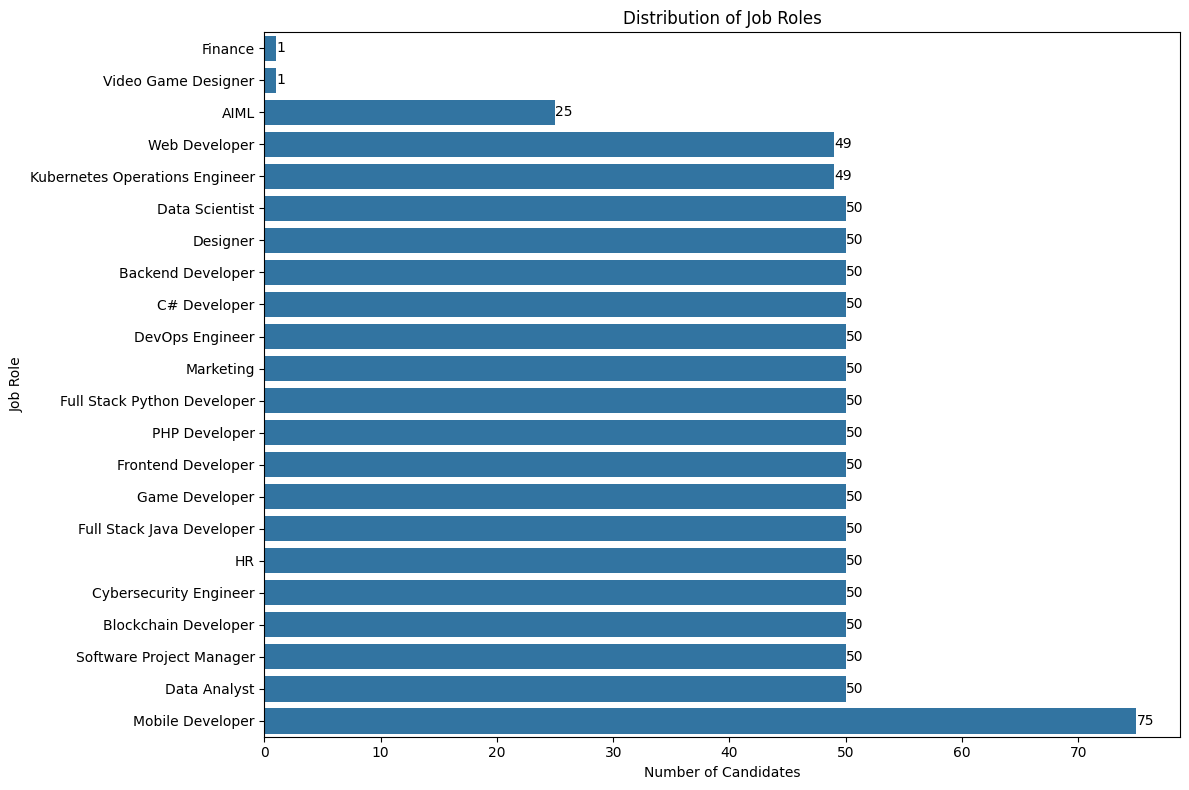

In [26]:
role_counts = df["job_role"].value_counts().sort_values()

plt.figure(figsize=(12, 8))

ax = sns.barplot(
    x=role_counts.values,
    y=role_counts.index
)

ax.bar_label(ax.containers[0])

plt.title("Distribution of Job Roles")
plt.xlabel("Number of Candidates")
plt.ylabel("Job Role")

plt.tight_layout()
plt.show()

In [27]:
print(df["skills"].head(20).to_string(index=False))

Python, SQL, TensorFlow, Machine Learning, Comm...
            HTML, CSS, JavaScript, React, Teamwork
     Java, Spring, SQL, REST APIs, Problem Solving
         Figma, Adobe XD, UI/UX Design, Creativity
          Python, Django, JavaScript, React, Agile
Financial Modeling, Excel, Communication, Risk ...
         C++, Unreal Engine, Game Design, Teamwork
             Kubernetes, Docker, AWS, CI/CD, Linux
       Java, Spring Boot, Hibernate, Microservices
        Solidity, Ethereum, JavaScript, Blockchain
Marketing Strategy, SEO, Content Creation, Anal...
Recruitment, HR Policies, Communication, Leader...
                            C#, .NET, SQL, ASP.NET
                   PHP, Laravel, MySQL, JavaScript
        Swift, iOS Development, Objective-C, UI/UX
  Network Security, Penetration Testing, Firewalls
      Agile, Scrum, Project Management, Leadership
              C++, Unity, Game Design, 3D Modeling
           Python, Pandas, SQL, Data Visualization
                  Kubernetes, H

In [29]:
df["skills_list"] = df["skills"].apply(
    lambda x: [
        skill.strip()
        for skill in str(x).split(",")
        if skill.strip()
    ]
)
df[["skills", "skills_list"]].head(10)

,skills,skills_list
0,"Python, SQL, TensorFlow, Machine Learning, Com...","[Python, SQL, TensorFlow, Machine Learning, Co..."
1,"HTML, CSS, JavaScript, React, Teamwork","[HTML, CSS, JavaScript, React, Teamwork]"
2,"Java, Spring, SQL, REST APIs, Problem Solving","[Java, Spring, SQL, REST APIs, Problem Solving]"
3,"Figma, Adobe XD, UI/UX Design, Creativity","[Figma, Adobe XD, UI/UX Design, Creativity]"
4,"Python, Django, JavaScript, React, Agile","[Python, Django, JavaScript, React, Agile]"
5,"Financial Modeling, Excel, Communication, Risk...","[Financial Modeling, Excel, Communication, Ris..."
6,"C++, Unreal Engine, Game Design, Teamwork","[C++, Unreal Engine, Game Design, Teamwork]"
7,"Kubernetes, Docker, AWS, CI/CD, Linux","[Kubernetes, Docker, AWS, CI/CD, Linux]"
8,"Java, Spring Boot, Hibernate, Microservices","[Java, Spring Boot, Hibernate, Microservices]"
9,"Solidity, Ethereum, JavaScript, Blockchain","[Solidity, Ethereum, JavaScript, Blockchain]"


In [30]:
all_skills = sorted(
    set(
        skill
        for skill_list in df["skills_list"]
        for skill in skill_list
    )
)

print("Total unique skills:", len(all_skills))
print("\nSkills:")
print(all_skills)

Total unique skills: 119

Skills:
['.NET', '.NET Core', '3D Modeling', 'ASP.NET', 'AWS', 'Adobe Illustrator', 'Adobe XD', 'Agile', 'Analytics', 'Android Development', 'Android SDK', 'Angular', 'Ansible', 'Azure', 'Blockchain', 'C#', 'C++', 'CI/CD', 'CSS', 'Communication', 'Content Creation', 'Core Data', 'Creativity', 'Data Analysis', 'Data Science', 'Data Visualization', 'Deep Learning', 'Digital Marketing', 'Django', 'Docker', 'Employee Relations', 'Ethereum', 'Ethical Hacking', 'Excel', 'Express', 'Figma', 'Financial Modeling', 'Firewalls', 'Flask', 'GCP', 'Game Design', 'Game Physics', 'Google Analytics', 'HR Management', 'HR Policies', 'HTML', 'Helm', 'Hibernate', 'JIRA', 'Java', 'JavaScript', 'Jenkins', 'Keras', 'Kotlin', 'Kubernetes', 'Laravel', 'Leadership', 'Linux', 'Machine Learning', 'Marketing Campaigns', 'Marketing Strategy', 'Microservices', 'MongoDB', 'MySQL', 'NLP', 'Network Security', 'Node.js', 'Objective-C', 'PHP', 'PPC', 'Pandas', 'Penetration Testing', 'Photoshop',

In [31]:
skill_counter = Counter(
    skill
    for skill_list in df["skills_list"]
    for skill in skill_list
)

skill_frequency = pd.DataFrame(
    skill_counter.items(),
    columns=["Skill", "Count"]
).sort_values(
    by="Count",
    ascending=False
)

skill_frequency.head(20)

,Skill,Count
7,JavaScript,200
0,Python,150
1,SQL,148
10,Java,125
28,AWS,123
53,UI/UX,97
8,React,75
5,HTML,75
6,CSS,75
27,Docker,74


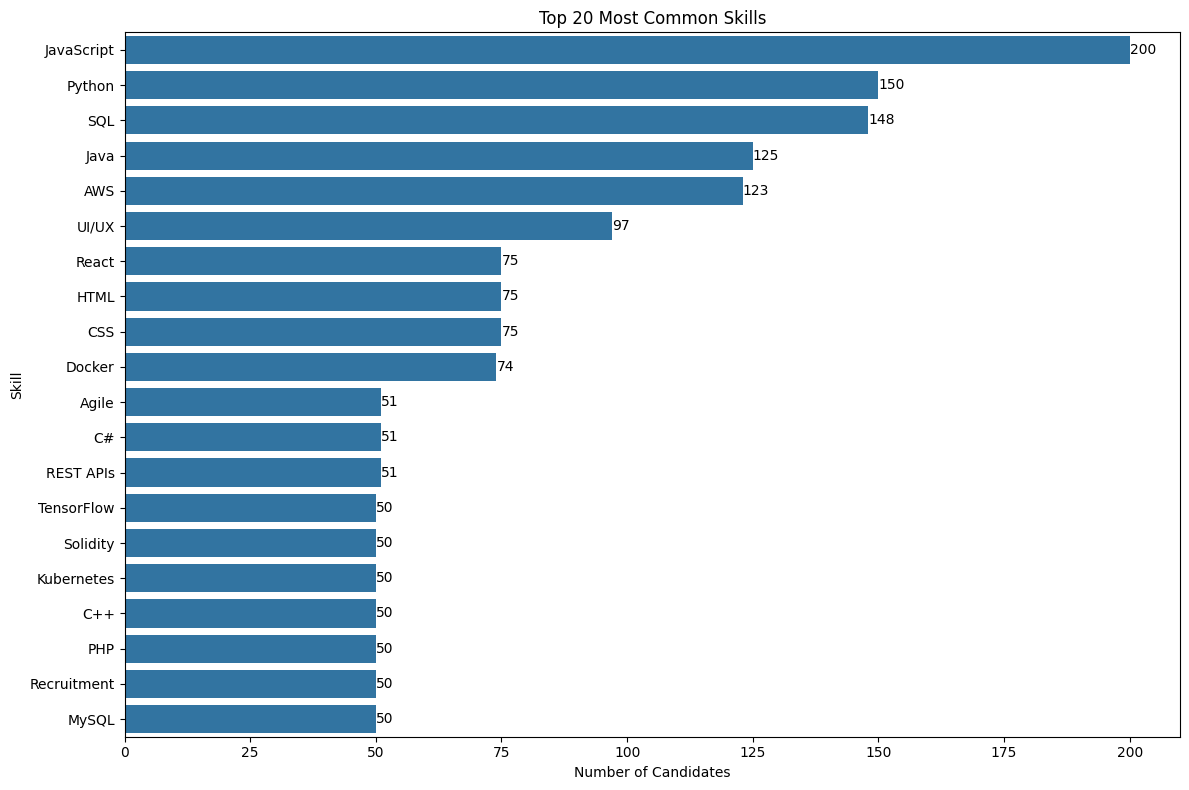

In [32]:
top_skills = skill_frequency.head(20)

plt.figure(figsize=(12, 8))

ax = sns.barplot(
    data=top_skills,
    x="Count",
    y="Skill"
)

ax.bar_label(ax.containers[0])

plt.title("Top 20 Most Common Skills")
plt.xlabel("Number of Candidates")
plt.ylabel("Skill")

plt.tight_layout()
plt.show()

In [ ]:
df["profile"] = df.apply(
    lambda row: (
        tuple(row["skills_list"]),
        row["qualification"],
        row["experience_level"],
    ),
    axis=1,
)

unique_profiles = df["profile"].drop_duplicates().reset_index(drop=True)

train_profiles, test_profiles = train_test_split(
    unique_profiles,
    test_size=0.20,
    random_state=42,
)

train_mask = df["profile"].isin(train_profiles)
test_mask = df["profile"].isin(test_profiles)

print("Unique profiles:", len(unique_profiles))
print("Train profiles:", len(train_profiles))
print("Test profiles:", len(test_profiles))
print("Profile overlap:", len(set(train_profiles) & set(test_profiles)))

train_skills = df.loc[train_mask, "skills_list"]
test_skills = df.loc[test_mask, "skills_list"]

mlb = MultiLabelBinarizer()

train_skill_matrix = mlb.fit_transform(train_skills)
test_skill_matrix = mlb.transform(test_skills)

skill_df_train = pd.DataFrame(
    train_skill_matrix,
    columns=mlb.classes_,
    index=df.index[train_mask],
)

skill_df_test = pd.DataFrame(
    test_skill_matrix,
    columns=mlb.classes_,
    index=df.index[test_mask],
)

print("Training skill feature shape:", skill_df_train.shape)
print("Testing skill feature shape:", skill_df_test.shape)

skill_df_train.head()


In [ ]:
train_features = pd.concat(
    [
        skill_df_train,
        df.loc[train_mask, ["qualification", "experience_level"]],
    ],
    axis=1,
)

test_features = pd.concat(
    [
        skill_df_test,
        df.loc[test_mask, ["qualification", "experience_level"]],
    ],
    axis=1,
)

X_train = train_features.reset_index(drop=True)
X_test = test_features.reset_index(drop=True)

y_train = df.loc[train_mask, "job_role"].reset_index(drop=True)
y_test = df.loc[test_mask, "job_role"].reset_index(drop=True)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


In [ ]:
skill_columns = skill_df_train.columns.tolist()

categorical_columns = [
    "qualification",
    "experience_level"
]

print("Num skill columns:", len(skill_columns))
print("Skill columns:", skill_columns[:10])


In [ ]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Profile overlap:", len(set(train_profiles) & set(test_profiles)))
assert len(set(train_profiles) & set(test_profiles)) == 0


In [41]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "skills",
            "passthrough",
            skill_columns
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_columns
        )
    ]
)
results = []

In [ ]:
logistic_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", logistic_model)
])

logistic_pipeline.fit(X_train, y_train)

y_pred_lr = logistic_pipeline.predict(X_test)
lr_accuracy = accuracy_score(
    y_test,
    y_pred_lr
)

print(f"Logistic Regression Accuracy: {lr_accuracy:.4f}")
lr_macro_f1 = f1_score(
    y_test,
    y_pred_lr,
    average="macro"
)
lr_weighted_f1 = f1_score(
    y_test,
    y_pred_lr,
    average="weighted"
)

print(f"Logistic Regression Macro F1: {lr_macro_f1:.4f}")
print(f"Logistic Regression Weighted F1: {lr_weighted_f1:.4f}")
print(classification_report(y_test, y_pred_lr))

y_prob_lr = logistic_pipeline.predict_proba(X_test)

lr_top3 = top_k_accuracy_score(
    y_test,
    y_prob_lr,
    k=3,
    labels=logistic_pipeline.classes_
)

lr_top5 = top_k_accuracy_score(
    y_test,
    y_prob_lr,
    k=5,
    labels=logistic_pipeline.classes_
)

print(f"Logistic Regression Top-3: {lr_top3:.4f}")
print(f"Logistic Regression Top-5: {lr_top5:.4f}")
results.append({
    "Model": "Logistic Regression",
    "Accuracy": lr_accuracy,
    "Macro F1": lr_macro_f1,
    "Weighted F1": lr_weighted_f1,
    "Top-3 Accuracy": lr_top3,
    "Top-5 Accuracy": lr_top5
})


In [ ]:
knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", knn_model)
])

knn_pipeline.fit(
    X_train,
    y_train
)
y_pred_knn = knn_pipeline.predict(X_test)
knn_accuracy = accuracy_score(
    y_test,
    y_pred_knn
)

knn_macro_f1 = f1_score(
    y_test,
    y_pred_knn,
    average="macro"
)
knn_weighted_f1 = f1_score(
    y_test,
    y_pred_knn,
    average="weighted"
)

print(f"KNN Accuracy: {knn_accuracy:.4f}")
print(f"KNN Macro F1: {knn_macro_f1:.4f}")
print(f"KNN Weighted F1: {knn_weighted_f1:.4f}")

y_prob_knn = knn_pipeline.predict_proba(X_test)

knn_top3 = top_k_accuracy_score(
    y_test,
    y_prob_knn,
    k=3,
    labels=knn_pipeline.classes_
)

knn_top5 = top_k_accuracy_score(
    y_test,
    y_prob_knn,
    k=5,
    labels=knn_pipeline.classes_
)

print(f"KNN Top-3 Accuracy: {knn_top3:.4f}")
print(f"KNN Top-5 Accuracy: {knn_top5:.4f}")
results.append({
    "Model": "KNN",
    "Accuracy": knn_accuracy,
    "Macro F1": knn_macro_f1,
    "Weighted F1": knn_weighted_f1,
    "Top-3 Accuracy": knn_top3,
    "Top-5 Accuracy": knn_top5
})


In [ ]:
dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", dt_model)
])

dt_pipeline.fit(
    X_train,
    y_train
)
y_pred_dt = dt_pipeline.predict(X_test)
dt_accuracy = accuracy_score(
    y_test,
    y_pred_dt
)

dt_macro_f1 = f1_score(
    y_test,
    y_pred_dt,
    average="macro"
)
dt_weighted_f1 = f1_score(
    y_test,
    y_pred_dt,
    average="weighted"
)

print(f"Decision Tree Accuracy: {dt_accuracy:.4f}")
print(f"Decision Tree Macro F1: {dt_macro_f1:.4f}")
print(f"Decision Tree Weighted F1: {dt_weighted_f1:.4f}")
y_prob_dt = dt_pipeline.predict_proba(X_test)

dt_top3 = top_k_accuracy_score(
    y_test,
    y_prob_dt,
    k=3,
    labels=dt_pipeline.classes_
)

dt_top5 = top_k_accuracy_score(
    y_test,
    y_prob_dt,
    k=5,
    labels=dt_pipeline.classes_
)

print(f"Decision Tree Top-3 Accuracy: {dt_top3:.4f}")
print(f"Decision Tree Top-5 Accuracy: {dt_top5:.4f}")
results.append({
    "Model": "Decision Tree",
    "Accuracy": dt_accuracy,
    "Macro F1": dt_macro_f1,
    "Weighted F1": dt_weighted_f1,
    "Top-3 Accuracy": dt_top3,
    "Top-5 Accuracy": dt_top5
})


In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", rf_model)
])
rf_pipeline.fit(
    X_train,
    y_train
)
y_pred_rf = rf_pipeline.predict(X_test)
rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

rf_macro_f1 = f1_score(
    y_test,
    y_pred_rf,
    average="macro"
)
rf_weighted_f1 = f1_score(
    y_test,
    y_pred_rf,
    average="weighted"
)

print(f"Random Forest Accuracy: {rf_accuracy:.4f}")
print(f"Random Forest Macro F1: {rf_macro_f1:.4f}")
print(f"Random Forest Weighted F1: {rf_weighted_f1:.4f}")

y_prob_rf = rf_pipeline.predict_proba(X_test)

rf_top3 = top_k_accuracy_score(
    y_test,
    y_prob_rf,
    k=3,
    labels=rf_pipeline.classes_
)

rf_top5 = top_k_accuracy_score(
    y_test,
    y_prob_rf,
    k=5,
    labels=rf_pipeline.classes_
)

print(f"Random Forest Top-3 Accuracy: {rf_top3:.4f}")
print(f"Random Forest Top-5 Accuracy: {rf_top5:.4f}")

results.append({
    "Model": "Random Forest",
    "Accuracy": rf_accuracy,
    "Macro F1": rf_macro_f1,
    "Weighted F1": rf_weighted_f1,
    "Top-3 Accuracy": rf_top3,
    "Top-5 Accuracy": rf_top5
})


In [ ]:
all_labels = pd.concat([y_train, y_test], ignore_index=True)

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(
    y_train
)

y_test_encoded = label_encoder.transform(
    y_test
)

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    eval_metric="mlogloss"
)

xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", xgb_model)
])

xgb_pipeline.fit(
    X_train,
    y_train_encoded
)

y_pred_xgb_encoded = xgb_pipeline.predict(
    X_test
)

y_pred_xgb = label_encoder.inverse_transform(
    y_pred_xgb_encoded.astype(int)
)

xgb_accuracy = accuracy_score(
    y_test,
    y_pred_xgb
)

xgb_macro_f1 = f1_score(
    y_test,
    y_pred_xgb,
    average="macro"
)
xgb_weighted_f1 = f1_score(
    y_test,
    y_pred_xgb,
    average="weighted"
)

print(f"XGBoost Accuracy: {xgb_accuracy:.4f}")
print(f"XGBoost Macro F1: {xgb_macro_f1:.4f}")
print(f"XGBoost Weighted F1: {xgb_weighted_f1:.4f}")

y_prob_xgb = xgb_pipeline.predict_proba(
    X_test
)

xgb_top3 = top_k_accuracy_score(
    y_test_encoded,
    y_prob_xgb,
    k=3,
    labels=xgb_pipeline.classes_
)

xgb_top5 = top_k_accuracy_score(
    y_test_encoded,
    y_prob_xgb,
    k=5,
    labels=xgb_pipeline.classes_
)

print(f"XGBoost Top-3 Accuracy: {xgb_top3:.4f}")
print(f"XGBoost Top-5 Accuracy: {xgb_top5:.4f}")

results.append({
    "Model": "XGBoost",
    "Accuracy": xgb_accuracy,
    "Macro F1": xgb_macro_f1,
    "Weighted F1": xgb_weighted_f1,
    "Top-3 Accuracy": xgb_top3,
    "Top-5 Accuracy": xgb_top5
})


In [48]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Top-3 Accuracy",
    ascending=False
).reset_index(drop=True)

results_df

,Model,Accuracy,Macro F1,Top-3 Accuracy
0,Logistic Regression,1.000,1.000000,1.000
1,KNN,1.000,1.000000,1.000
2,Random Forest,1.000,1.000000,1.000
3,Decision Tree,0.995,0.993281,0.995
4,XGBoost,0.995,0.950311,0.995


In [ ]:
dummy_model = DummyClassifier(
    strategy="most_frequent"
)

dummy_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", dummy_model)
])

dummy_pipeline.fit(
    X_train,
    y_train
)

dummy_pred = dummy_pipeline.predict(
    X_test
)

dummy_accuracy = accuracy_score(
    y_test,
    dummy_pred
)

dummy_macro_f1 = f1_score(
    y_test,
    dummy_pred,
    average="macro"
)
dummy_weighted_f1 = f1_score(
    y_test,
    dummy_pred,
    average="weighted"
)

print(f"Dummy Accuracy: {dummy_accuracy:.4f}")
print(f"Dummy Macro F1: {dummy_macro_f1:.4f}")
print(f"Dummy Weighted F1: {dummy_weighted_f1:.4f}")

dummy_prob = dummy_pipeline.predict_proba(
    X_test
)

dummy_top3 = top_k_accuracy_score(
    y_test,
    dummy_prob,
    k=3,
    labels=dummy_pipeline.classes_
)

dummy_top5 = top_k_accuracy_score(
    y_test,
    dummy_prob,
    k=5,
    labels=dummy_pipeline.classes_
)

print(f"Dummy Top-3 Accuracy: {dummy_top3:.4f}")
print(f"Dummy Top-5 Accuracy: {dummy_top5:.4f}")

results.append({
    "Model": "DummyClassifier",
    "Accuracy": dummy_accuracy,
    "Macro F1": dummy_macro_f1,
    "Weighted F1": dummy_weighted_f1,
    "Top-3 Accuracy": dummy_top3,
    "Top-5 Accuracy": dummy_top5
})


In [50]:
lr_top5 = top_k_accuracy_score(
    y_test,
    y_prob_lr,
    k=5,
    labels=logistic_pipeline.classes_
)

knn_top5 = top_k_accuracy_score(
    y_test,
    y_prob_knn,
    k=5,
    labels=knn_pipeline.classes_
)

dt_top5 = top_k_accuracy_score(
    y_test,
    y_prob_dt,
    k=5,
    labels=dt_pipeline.classes_
)

rf_top5 = top_k_accuracy_score(
    y_test,
    y_prob_rf,
    k=5,
    labels=rf_pipeline.classes_
)

xgb_top5 = top_k_accuracy_score(
    y_test_encoded,
    y_prob_xgb,
    k=5,
    labels=xgb_pipeline.classes_
)

print("Logistic Regression Top-5:", round(lr_top5, 4))
print("KNN Top-5:", round(knn_top5, 4))
print("Decision Tree Top-5:", round(dt_top5, 4))
print("Random Forest Top-5:", round(rf_top5, 4))
print("XGBoost Top-5:", round(xgb_top5, 4))

Logistic Regression Top-5: 1.0
KNN Top-5: 1.0
Decision Tree Top-5: 0.995
Random Forest Top-5: 1.0
XGBoost Top-5: 0.995


In [ ]:
dummy_top5 = top_k_accuracy_score(
    y_test,
    dummy_prob,
    k=5,
    labels=dummy_pipeline.classes_
)

top5_values = {
    "Logistic Regression": lr_top5,
    "KNN": knn_top5,
    "Decision Tree": dt_top5,
    "Random Forest": rf_top5,
    "XGBoost": xgb_top5,
    "DummyClassifier": dummy_top5
}

results_df = pd.DataFrame(results)
results_df["Top-5 Accuracy"] = results_df["Model"].map(
    top5_values
)


NameError: name 'y_test' is not defined

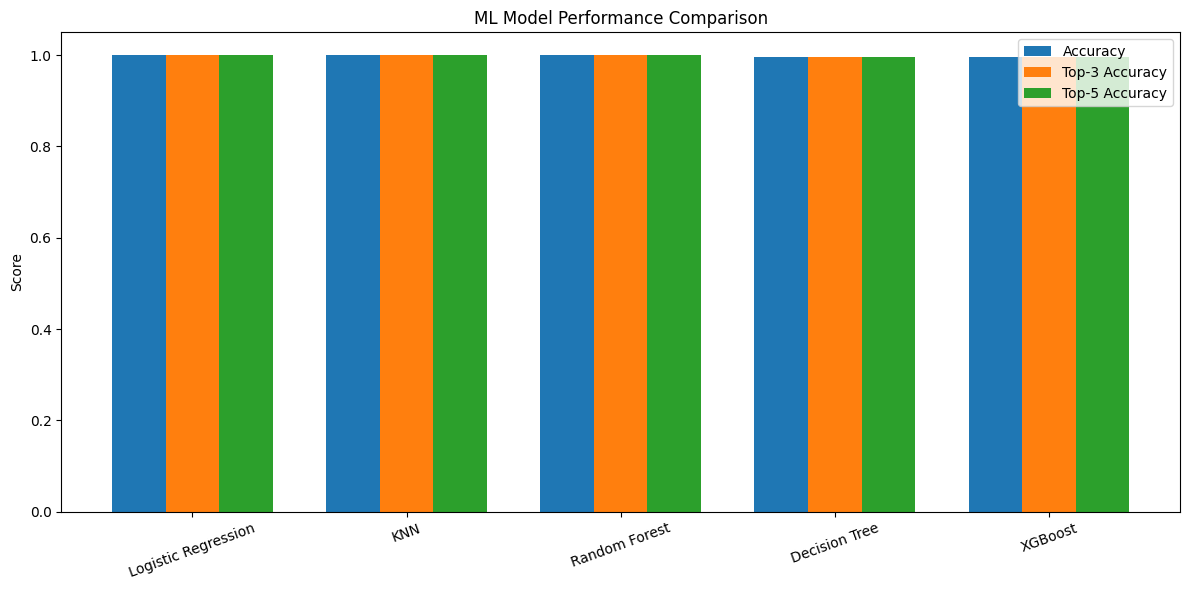

In [52]:
plt.figure(figsize=(12, 6))

x = np.arange(len(results_df))
width = 0.25

plt.bar(
    x - width,
    results_df["Accuracy"],
    width,
    label="Accuracy"
)

plt.bar(
    x,
    results_df["Top-3 Accuracy"],
    width,
    label="Top-3 Accuracy"
)

plt.bar(
    x + width,
    results_df["Top-5 Accuracy"],
    width,
    label="Top-5 Accuracy"
)

plt.xticks(
    x,
    results_df["Model"],
    rotation=20
)

plt.ylabel("Score")
plt.title("ML Model Performance Comparison")
plt.legend()

plt.tight_layout()
plt.show()

In [5]:
results_df.sort_values(
    by="Top-3 Accuracy",
    ascending=False
)
results_df.sort_values(
    by="Macro F1",
    ascending=False
)

NameError: name 'results_df' is not defined

In [54]:
print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

                                precision    recall  f1-score   support

                          AIML       1.00      1.00      1.00         7
             Backend Developer       1.00      1.00      1.00         7
          Blockchain Developer       1.00      1.00      1.00         7
                  C# Developer       1.00      1.00      1.00        11
        Cybersecurity Engineer       1.00      1.00      1.00        13
                  Data Analyst       1.00      1.00      1.00        11
                Data Scientist       1.00      1.00      1.00         9
                      Designer       1.00      1.00      1.00        12
               DevOps Engineer       1.00      1.00      1.00         8
            Frontend Developer       1.00      1.00      1.00         8
     Full Stack Java Developer       1.00      1.00      1.00         5
   Full Stack Python Developer       1.00      1.00      1.00        12
                Game Developer       1.00      1.00      1.00  

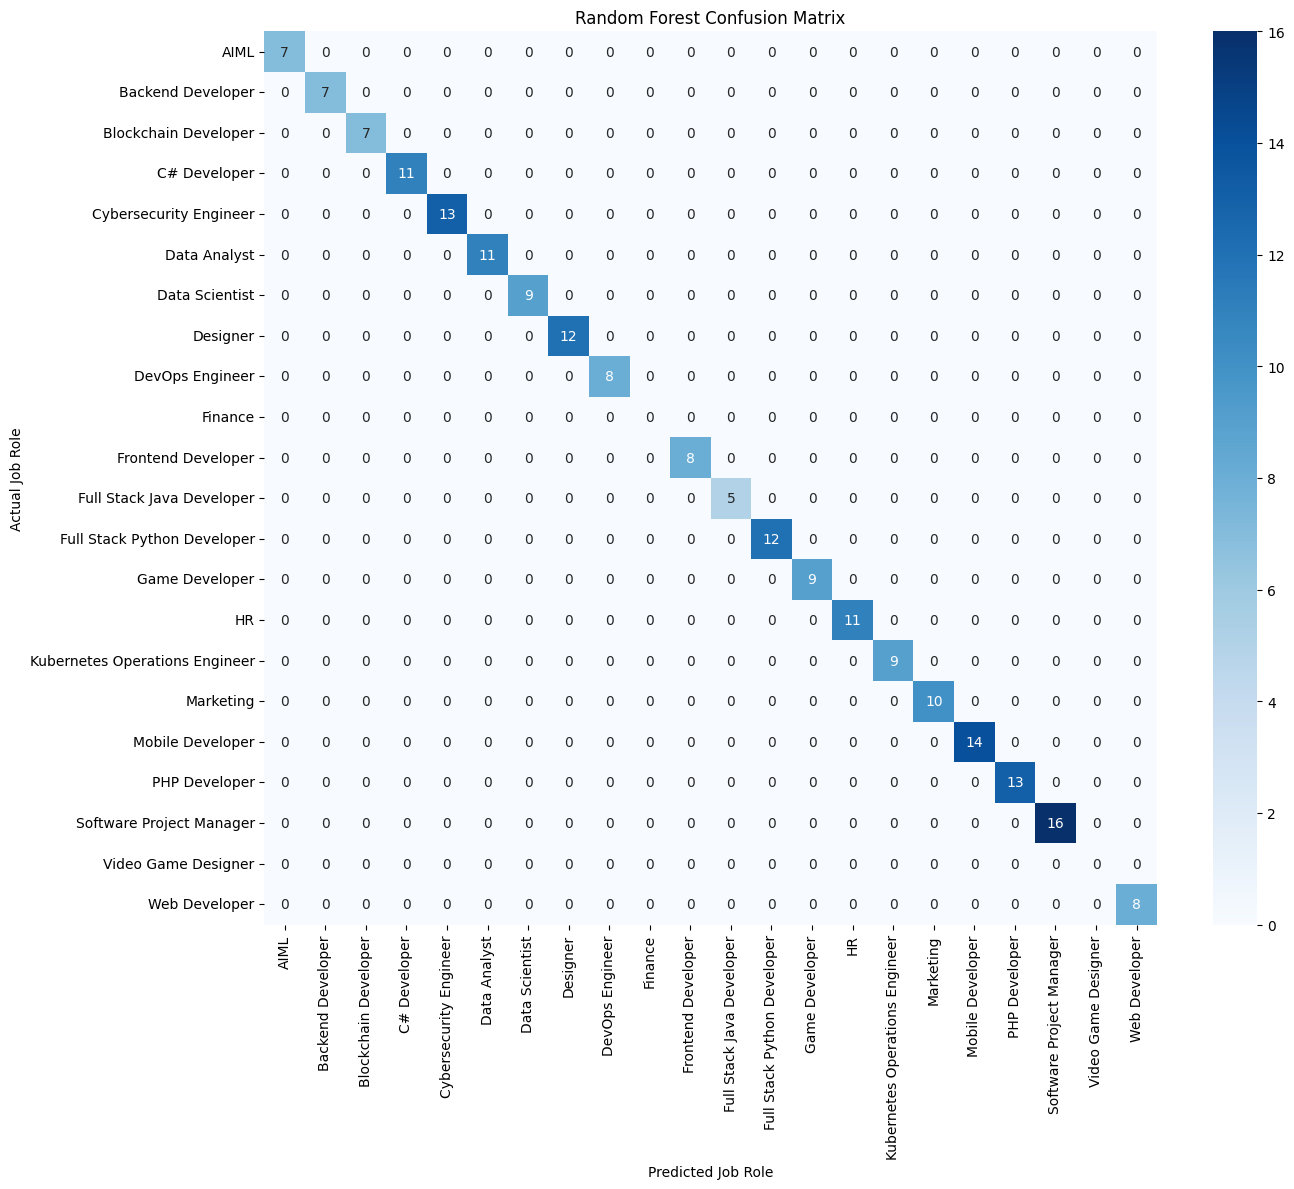

In [55]:
cm = confusion_matrix(
    y_test,
    y_pred_rf,
    labels=rf_pipeline.classes_
)

plt.figure(figsize=(14, 12))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=rf_pipeline.classes_,
    yticklabels=rf_pipeline.classes_
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Job Role")
plt.ylabel("Actual Job Role")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [56]:
feature_names = (
    rf_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

In [57]:
importances = (
    rf_pipeline
    .named_steps["model"]
    .feature_importances_
)

In [59]:
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(
    by="Importance",
    ascending=False
)
importance_df.head(20)

,Feature,Importance
119,categorical__qualification_Bachelor's in Compu...,0.030505
122,categorical__qualification_Bachelor's in Game ...,0.030494
86,skills__SQL,0.026387
125,categorical__qualification_Bachelor's in Marke...,0.025380
54,skills__Kubernetes,0.024703
134,categorical__qualification_Master's in Softwar...,0.024440
124,categorical__qualification_Bachelor's in Infor...,0.023830
49,skills__Java,0.023768
77,skills__Python,0.023733
139,categorical__experience_level_Senior,0.023157


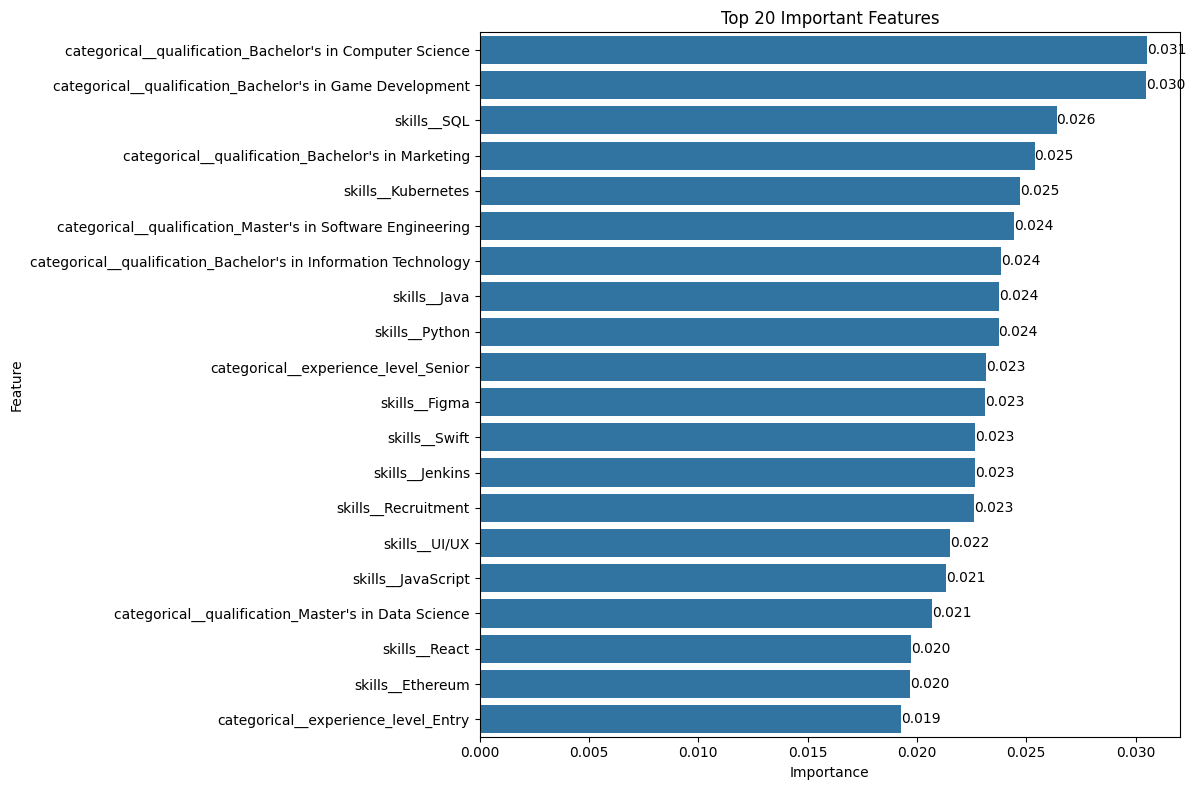

In [60]:
top_importance = importance_df.head(20)

plt.figure(figsize=(12, 8))

ax = sns.barplot(
    data=top_importance,
    x="Importance",
    y="Feature"
)

ax.bar_label(
    ax.containers[0],
    fmt="%.3f"
)

plt.title("Top 20 Important Features")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [3]:
results_df.sort_values(
    by=["Macro F1", "Top-3 Accuracy"],
    ascending=False
)

NameError: name 'results_df' is not defined

In [ ]:
import joblib
import os

os.makedirs('../models', exist_ok=True)
# Random Forest happens to be one of the best performing models, let's save the pipeline
joblib.dump(rf_pipeline, '../models/rf_model_pipeline.pkl')
print('Model saved to ../models/rf_model_pipeline.pkl')